In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

In [3]:
file_path = "gaming_mental_health_10M_40features.csv"

# Hızlı çalışma için ilk 100k satır
df = pd.read_csv(file_path, nrows=100_000)

print(df.shape)
df.head()

(100000, 39)


,age,gender,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,...,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
0,51,Female,8615,3.68,22,17,5.26,1.00,0.18,3,...,0,2.87,3.19,5.20,19.69,4.71,5.71,4.81,80,10
1,41,Female,39453,5.70,34,16,9.20,0.70,1.44,8,...,7,4.17,7.73,5.40,26.37,6.62,6.77,3.99,57,2
2,27,Male,40466,1.58,8,22,7.39,2.24,3.15,3,...,9,9.38,2.85,5.17,25.15,9.30,2.16,4.75,59,10
3,55,Male,51076,6.11,39,24,7.99,1.65,2.80,1,...,5,8.24,7.19,8.62,26.42,13.81,4.72,5.37,89,1
4,20,Male,86116,3.65,17,0,7.12,1.02,1.01,2,...,9,6.65,2.53,9.71,25.75,10.74,3.90,6.44,15,10


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nDuplicate Count:", df.duplicated().sum())

Shape: (100000, 39)

Columns:
['age', 'gender', 'income', 'daily_gaming_hours', 'weekly_sessions', 'years_gaming', 'sleep_hours', 'caffeine_intake', 'exercise_hours', 'stress_level', 'anxiety_score', 'depression_score', 'social_interaction_score', 'relationship_satisfaction', 'academic_performance', 'work_productivity', 'addiction_level', 'multiplayer_ratio', 'toxic_exposure', 'violent_games_ratio', 'mobile_gaming_ratio', 'night_gaming_ratio', 'weekend_gaming_hours', 'friends_gaming_count', 'online_friends', 'streaming_hours', 'esports_interest', 'headset_usage', 'microtransactions_spending', 'parental_supervision', 'loneliness_score', 'aggression_score', 'happiness_score', 'bmi', 'screen_time_total', 'eye_strain_score', 'back_pain_score', 'competitive_rank', 'internet_quality']

Data Types:
age                             int64
gender                         object
income                          int64
daily_gaming_hours            float64
weekly_sessions                 int64
years_g

In [5]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical Columns:", cat_cols)
print("\nNumber of Numerical Columns:", len(num_cols))

Categorical Columns: ['gender']

Number of Numerical Columns: 38


In [ ]:
df[num_cols].describe().T  # .T --> for Transpoze

,count,mean,std,min,25%,50%,75%,max
age,100000.0,36.022480,13.526548,13.00,24.00,36.000,48.0000,59.00
income,100000.0,77379.598860,41798.106945,5000.00,41152.00,77227.000,113571.2500,149998.00
daily_gaming_hours,100000.0,4.013554,2.843960,0.01,1.92,3.370,5.4000,26.55
weekly_sessions,100000.0,19.977250,11.271929,1.00,10.00,20.000,30.0000,39.00
years_gaming,100000.0,11.986810,7.210685,0.00,6.00,12.000,18.0000,24.00
sleep_hours,100000.0,7.002339,1.505066,0.78,5.99,7.000,8.0100,13.99
caffeine_intake,100000.0,1.997696,1.993872,0.00,0.57,1.380,2.7725,24.10
exercise_hours,100000.0,1.994194,2.000354,0.00,0.58,1.380,2.7600,22.34
stress_level,100000.0,5.490720,2.874578,1.00,3.00,5.000,8.0000,10.00
anxiety_score,100000.0,5.000353,1.982227,0.00,3.65,5.010,6.3400,10.00


In [7]:
target = "addiction_level"

df[target].describe()

count    100000.000000
mean          2.834825
std           2.117243
min           0.000000
25%           1.250000
50%           2.470000
75%           4.010000
max          10.000000
Name: addiction_level, dtype: float64

In [8]:
df = df.drop_duplicates().copy()

print("New shape after duplicate removal:", df.shape)

New shape after duplicate removal: (100000, 39)


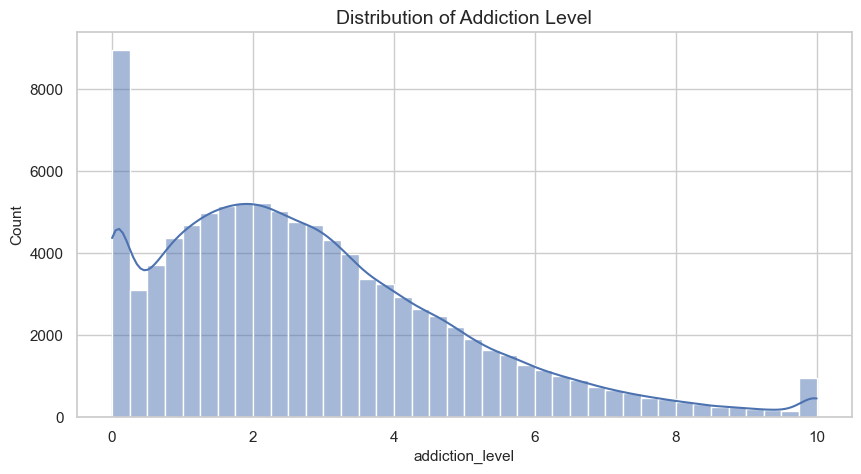

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df[target], bins=40, kde=True)
plt.title("Distribution of Addiction Level")
plt.xlabel("addiction_level")
plt.ylabel("Count")
plt.show()

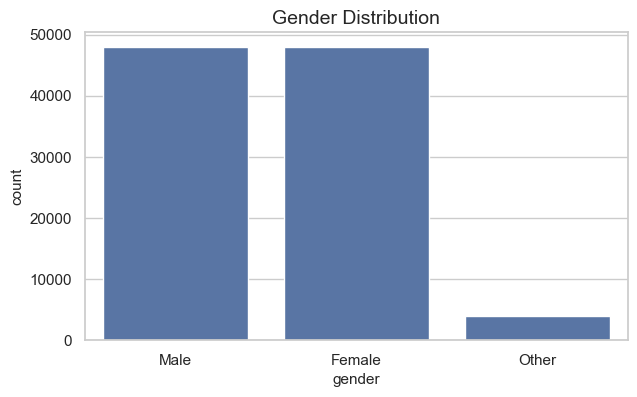

In [10]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="gender", order=df["gender"].value_counts().index)
plt.title("Gender Distribution")
plt.show()

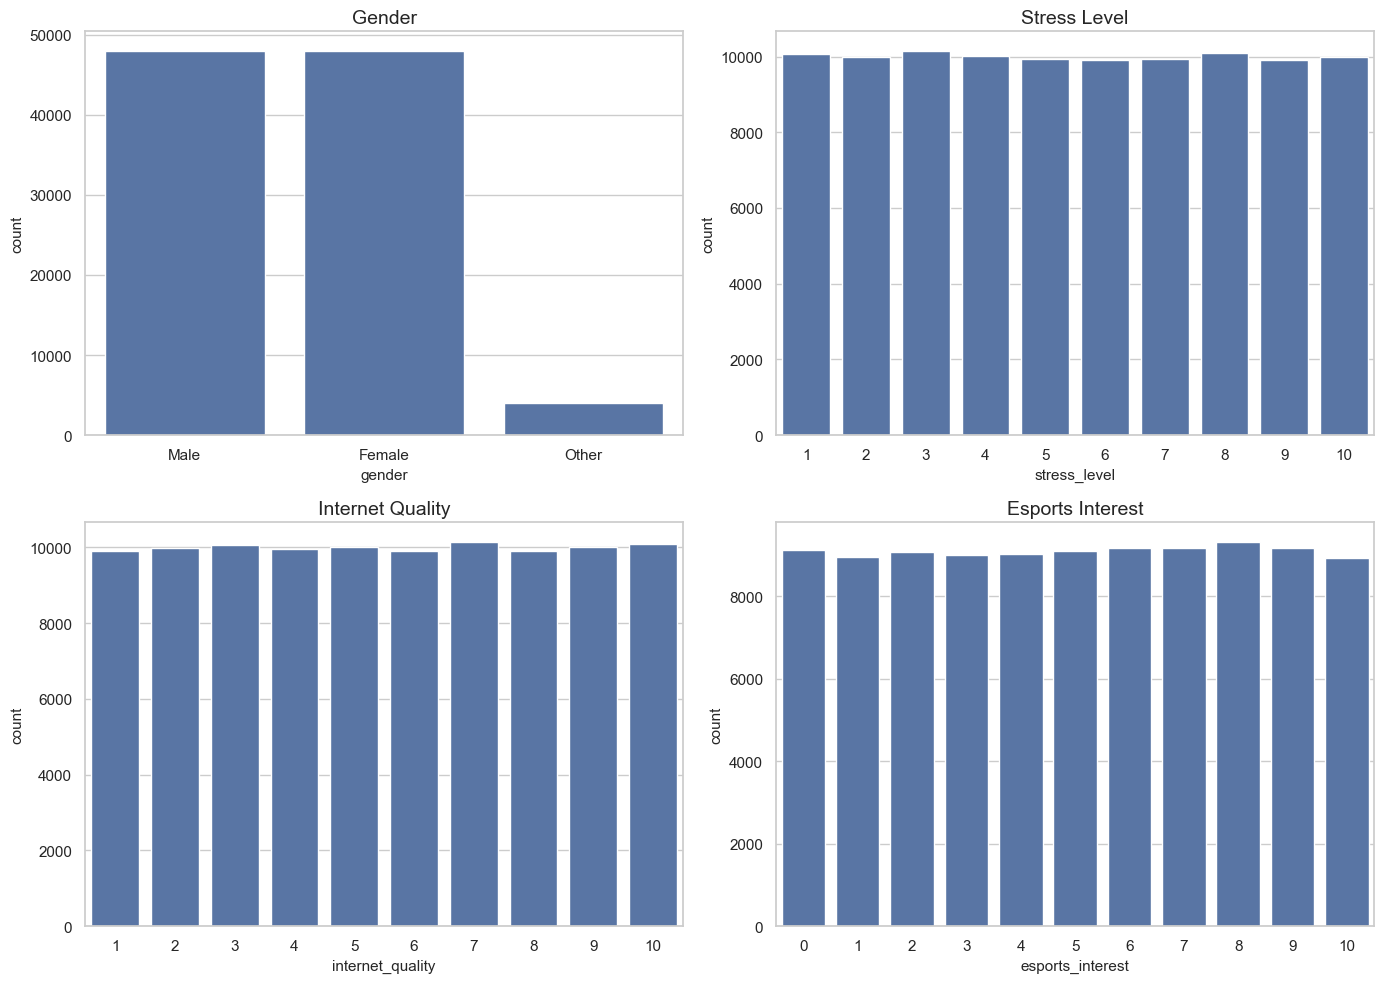

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x="gender", ax=axes[0, 0], order=df["gender"].value_counts().index)
axes[0, 0].set_title("Gender")

sns.countplot(data=df, x="stress_level", ax=axes[0, 1])
axes[0, 1].set_title("Stress Level")

sns.countplot(data=df, x="internet_quality", ax=axes[1, 0])
axes[1, 0].set_title("Internet Quality")

sns.countplot(data=df, x="esports_interest", ax=axes[1, 1])
axes[1, 1].set_title("Esports Interest")

plt.tight_layout()
plt.show()

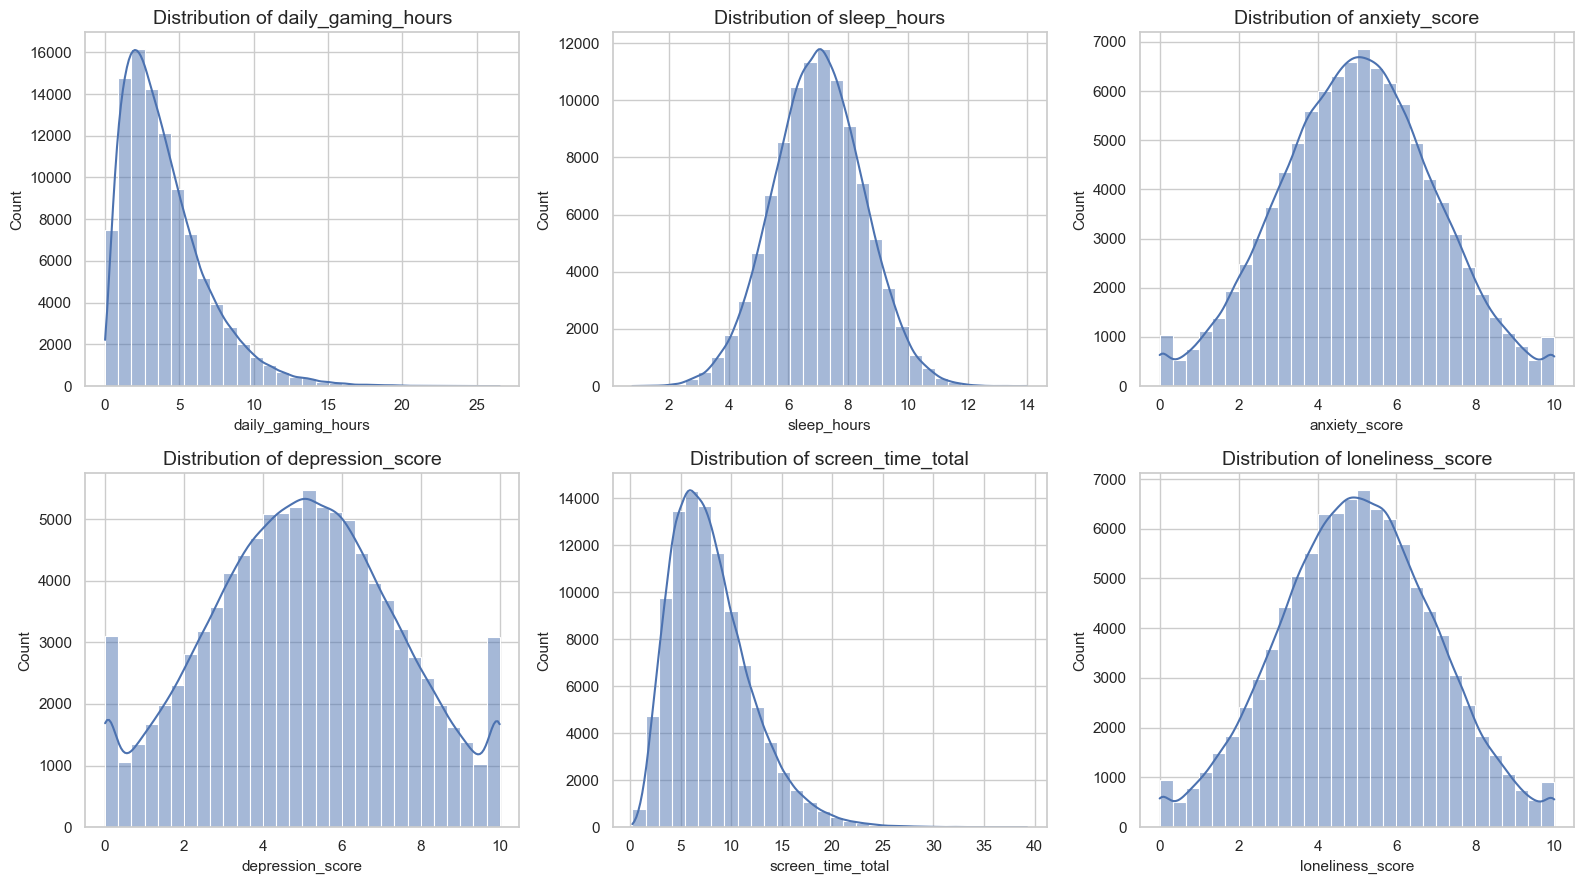

In [12]:
selected_num_cols = [
    "daily_gaming_hours",
    "sleep_hours",
    "anxiety_score",
    "depression_score",
    "screen_time_total",
    "loneliness_score"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(selected_num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

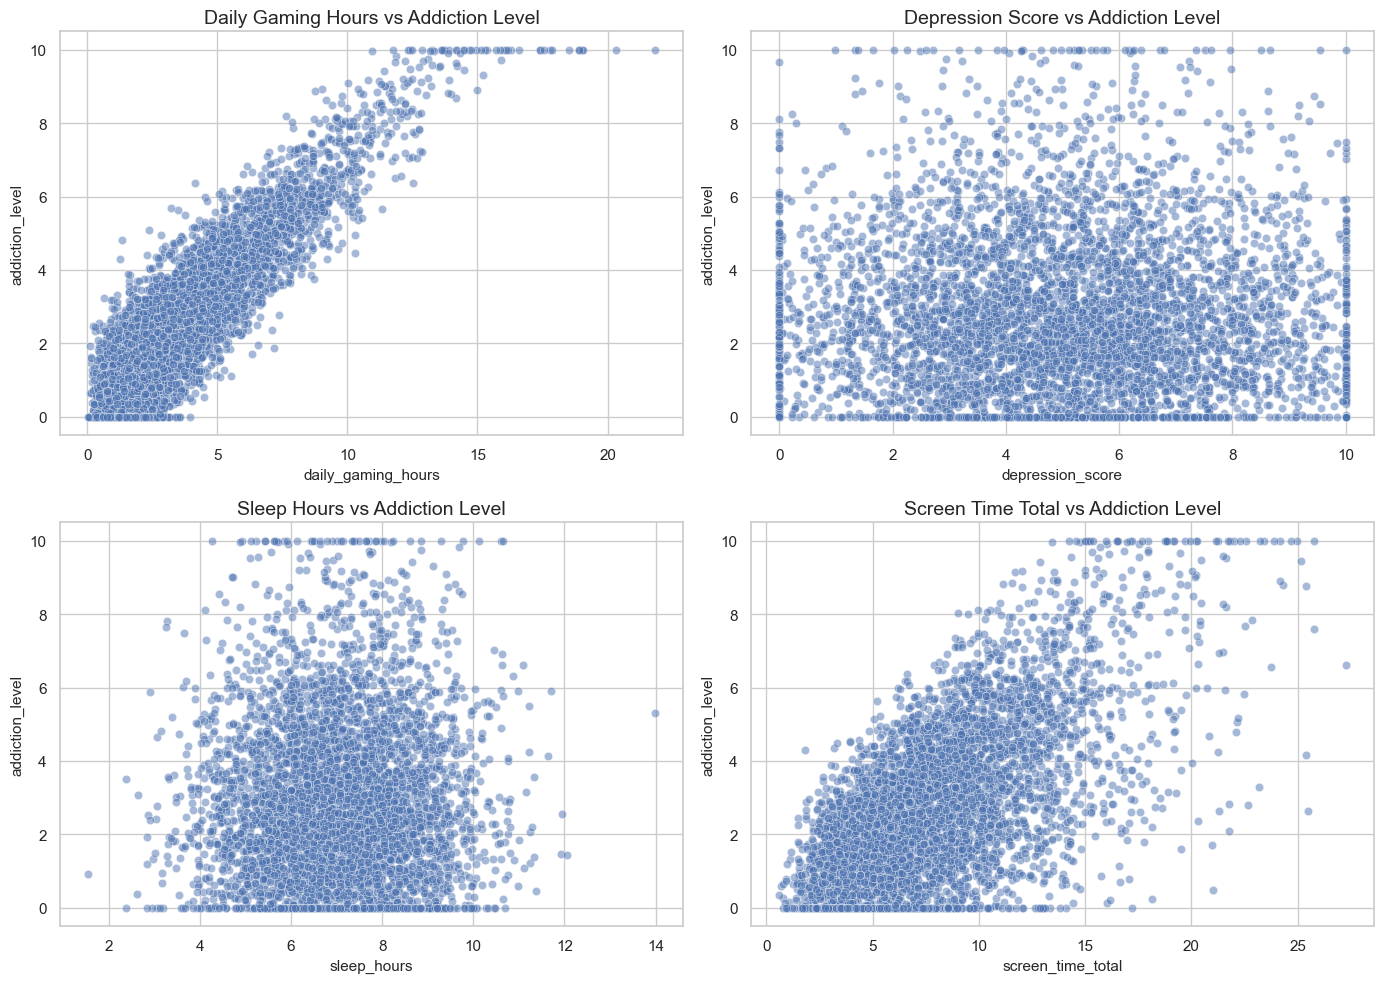

In [13]:
sample_viz = df.sample(5000, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=sample_viz, x="daily_gaming_hours", y=target, alpha=0.5, ax=axes[0, 0])
axes[0, 0].set_title("Daily Gaming Hours vs Addiction Level")

sns.scatterplot(data=sample_viz, x="depression_score", y=target, alpha=0.5, ax=axes[0, 1])
axes[0, 1].set_title("Depression Score vs Addiction Level")

sns.scatterplot(data=sample_viz, x="sleep_hours", y=target, alpha=0.5, ax=axes[1, 0])
axes[1, 0].set_title("Sleep Hours vs Addiction Level")

sns.scatterplot(data=sample_viz, x="screen_time_total", y=target, alpha=0.5, ax=axes[1, 1])
axes[1, 1].set_title("Screen Time Total vs Addiction Level")

plt.tight_layout()
plt.show()

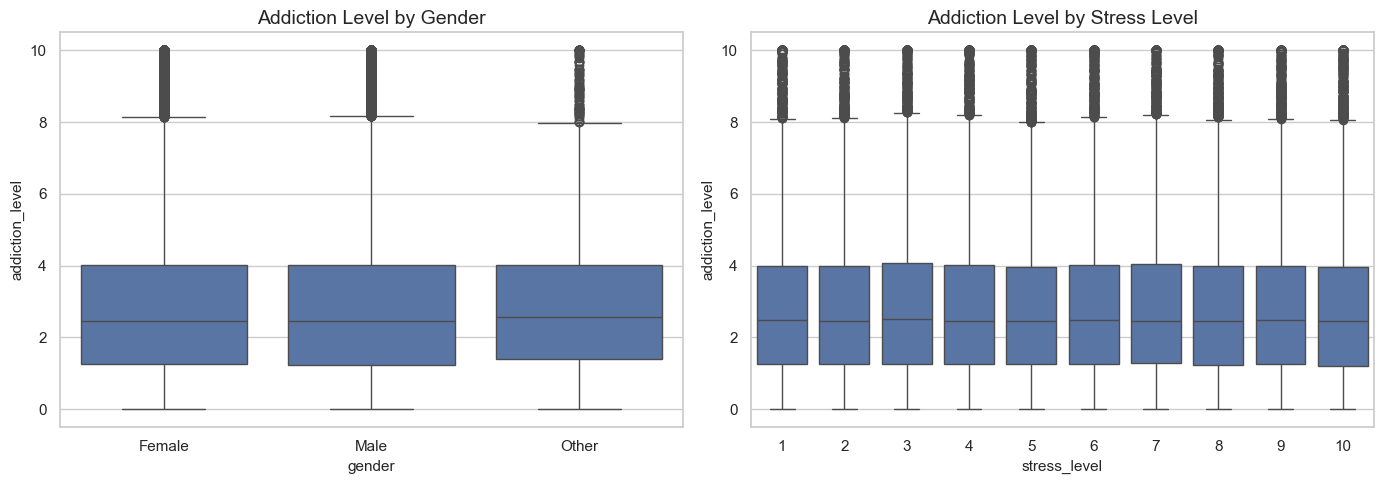

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="gender", y=target, ax=axes[0])
axes[0].set_title("Addiction Level by Gender")

sns.boxplot(data=df, x="stress_level", y=target, ax=axes[1])
axes[1].set_title("Addiction Level by Stress Level")

plt.tight_layout()
plt.show()

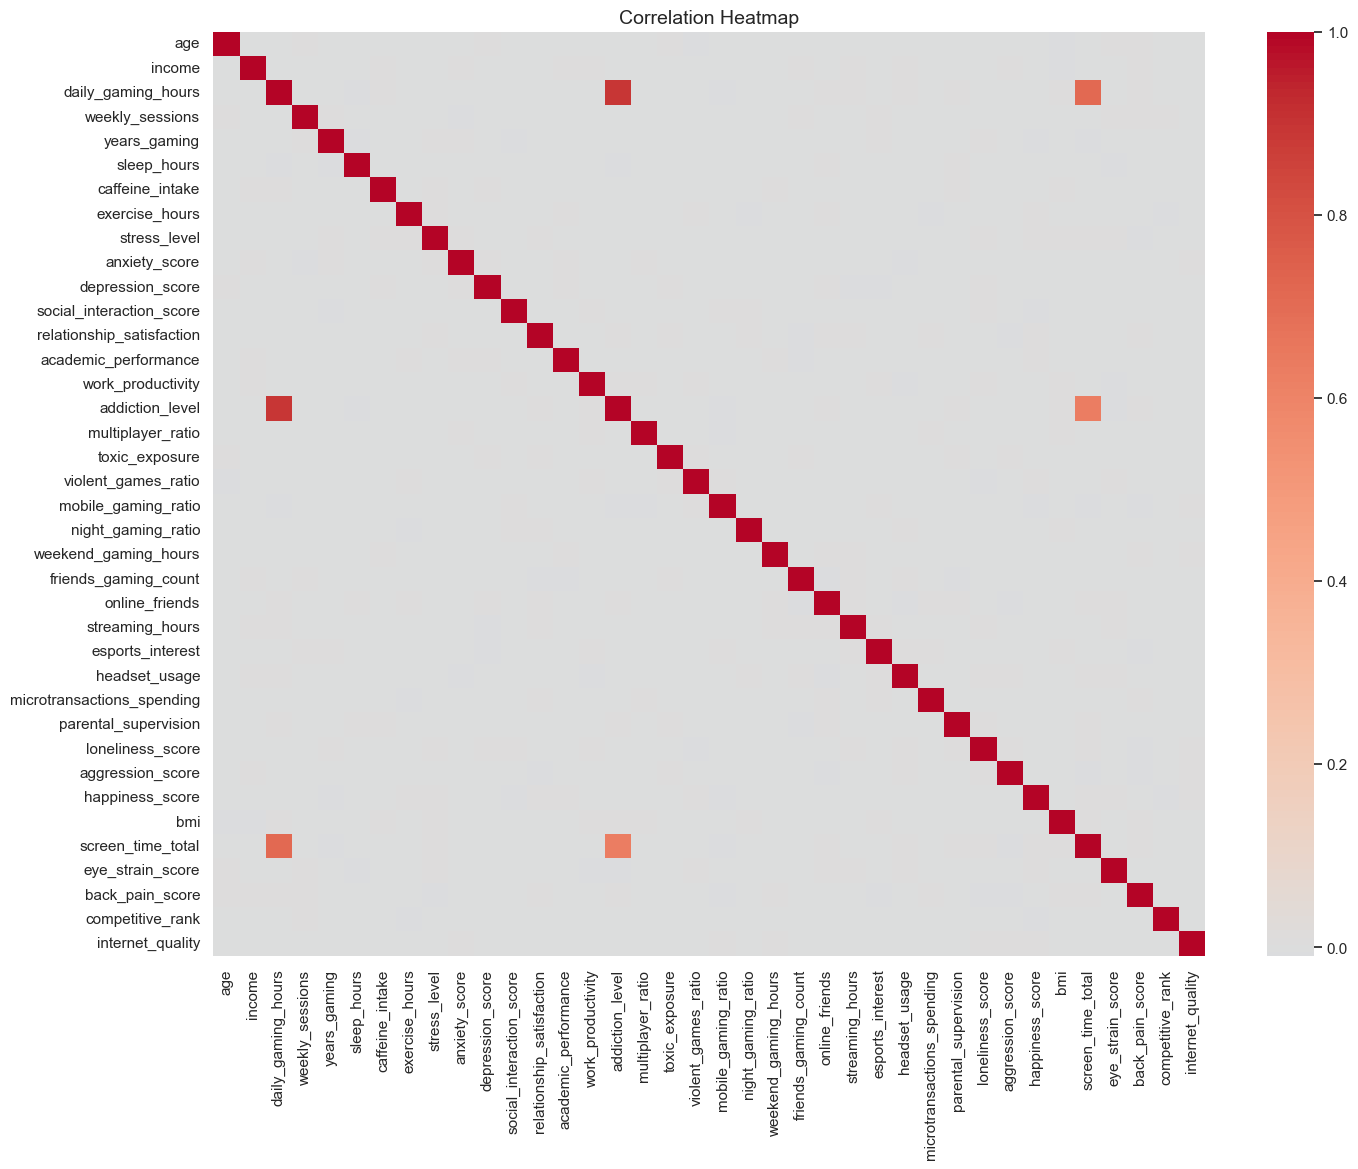

In [15]:
corr = df[num_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

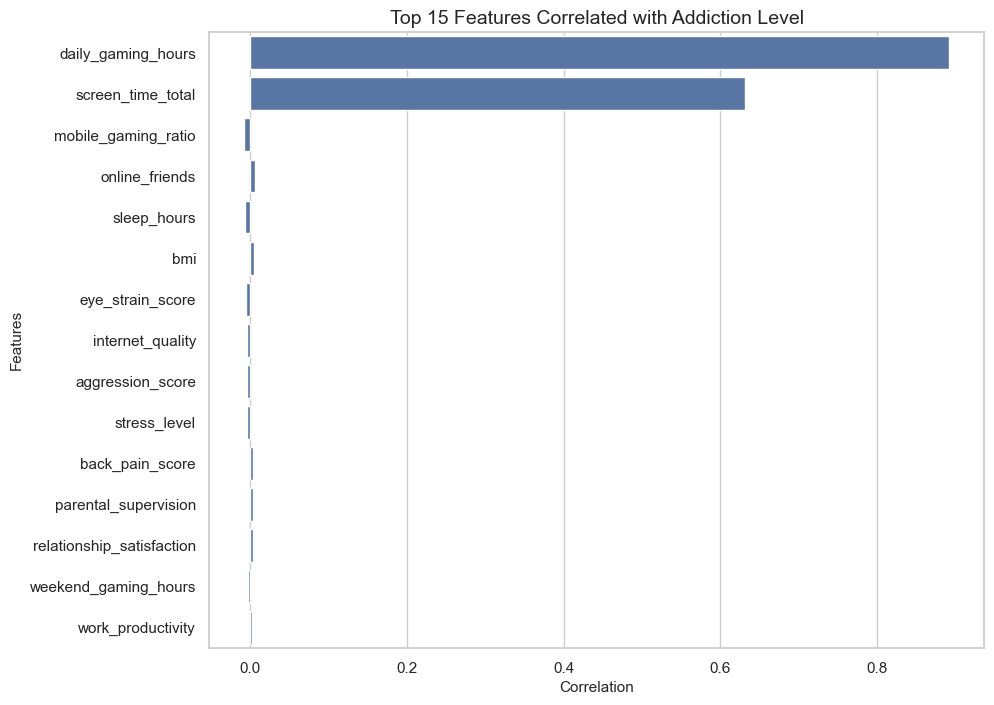

daily_gaming_hours           0.891654
screen_time_total            0.631915
mobile_gaming_ratio         -0.007174
online_friends               0.006623
sleep_hours                 -0.006377
bmi                          0.005561
eye_strain_score            -0.005358
internet_quality            -0.004455
aggression_score            -0.004055
stress_level                -0.003609
back_pain_score              0.003447
parental_supervision         0.003343
relationship_satisfaction    0.003329
weekend_gaming_hours        -0.003108
work_productivity            0.002942
Name: addiction_level, dtype: float64

In [16]:
target_corr = corr[target].drop(target).sort_values(key=np.abs, ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=target_corr.values[:15], y=target_corr.index[:15])
plt.title("Top 15 Features Correlated with Addiction Level")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.show()

target_corr.head(15)

In [17]:
X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100000, 38)
y shape: (100000,)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(80000, 38) (20000, 38)


In [19]:
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [20]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Results")
print("MAE :", ridge_mae)
print("RMSE:", ridge_rmse)
print("R2  :", ridge_r2)

Ridge Results
MAE : 0.7623567342572655
RMSE: 0.9532967736695677
R2  : 0.7972344997856396


In [21]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=150,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

Random Forest Results
MAE : 0.7559647296751904
RMSE: 0.9433365691595468
R2  : 0.80144942092968


In [22]:
hgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingRegressor(
        max_iter=250,
        learning_rate=0.08,
        max_depth=8,
        random_state=42
    ))
])

hgb_model.fit(X_train, y_train)

hgb_pred = hgb_model.predict(X_test)

hgb_mae = mean_absolute_error(y_test, hgb_pred)
hgb_rmse = np.sqrt(mean_squared_error(y_test, hgb_pred))
hgb_r2 = r2_score(y_test, hgb_pred)

print("HistGradientBoosting Results")
print("MAE :", hgb_mae)
print("RMSE:", hgb_rmse)
print("R2  :", hgb_r2)

HistGradientBoosting Results
MAE : 0.7562255888635564
RMSE: 0.9423281533680193
R2  : 0.8018736905459515


In [23]:
results = pd.DataFrame({
    "Model": ["Ridge", "RandomForest", "HistGradientBoosting"],
    "MAE": [ridge_mae, rf_mae, hgb_mae],
    "RMSE": [ridge_rmse, rf_rmse, hgb_rmse],
    "R2": [ridge_r2, rf_r2, hgb_r2]
}).sort_values(by="R2", ascending=False)

results

,Model,MAE,RMSE,R2
2,HistGradientBoosting,0.756226,0.942328,0.801874
1,RandomForest,0.755965,0.943337,0.801449
0,Ridge,0.762357,0.953297,0.797234


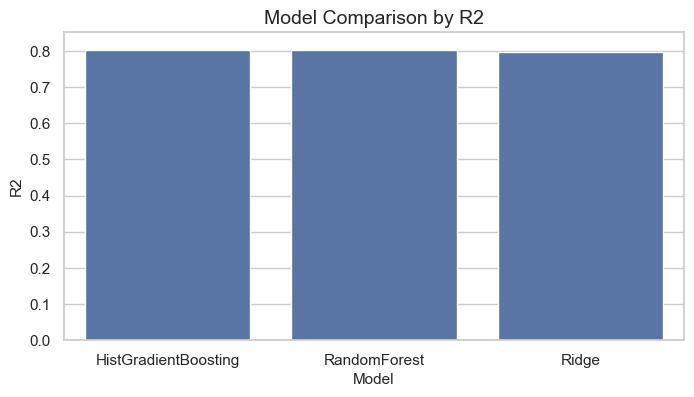

In [24]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results, x="Model", y="R2")
plt.title("Model Comparison by R2")
plt.ylim(0, max(results["R2"]) + 0.05)
plt.show()

In [26]:
model_dict = {
    "Ridge": ridge_model,
    "RandomForest": rf_model,
    "HistGradientBoosting": hgb_model
}

best_model = model_dict[best_model_name]

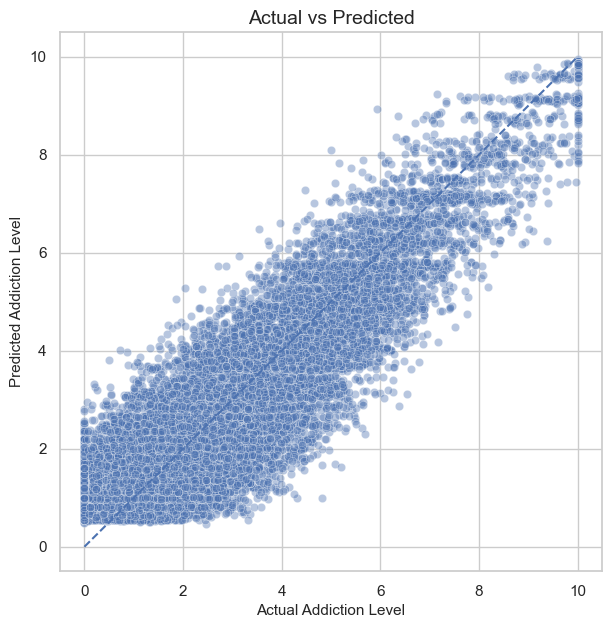

In [27]:
final_pred = best_model.predict(X_test)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=final_pred, alpha=0.4)
plt.xlabel("Actual Addiction Level")
plt.ylabel("Predicted Addiction Level")
plt.title("Actual vs Predicted")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.show()

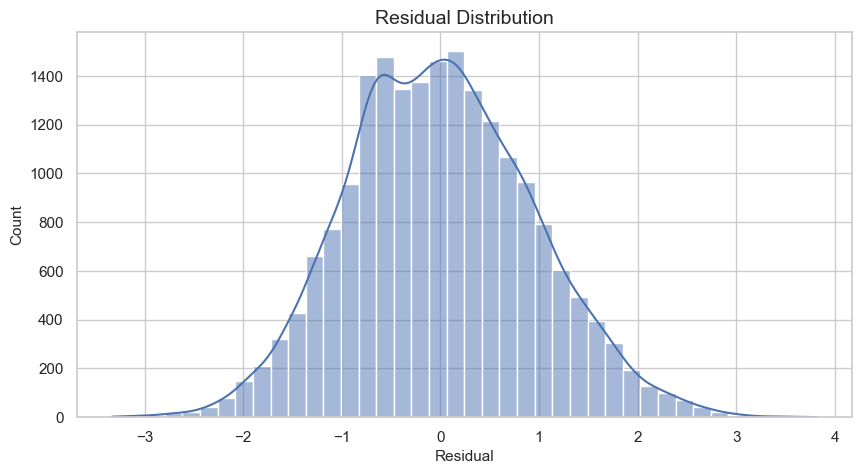

In [28]:
residuals = y_test - final_pred

plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.show()

In [29]:
rf_model.fit(X_train, y_train)

preprocessor_fitted = rf_model.named_steps["preprocessor"]
rf_fitted = rf_model.named_steps["model"]

feature_names = preprocessor_fitted.get_feature_names_out()
importances = rf_fitted.feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_imp.head(20)

,feature,importance
2,num__daily_gaming_hours,0.947696
1,num__income,0.001885
14,num__work_productivity,0.001817
32,num__screen_time_total,0.001811
11,num__social_interaction_score,0.001795
31,num__bmi,0.001780
9,num__anxiety_score,0.001752
23,num__streaming_hours,0.001752
26,num__microtransactions_spending,0.001736
20,num__weekend_gaming_hours,0.001725


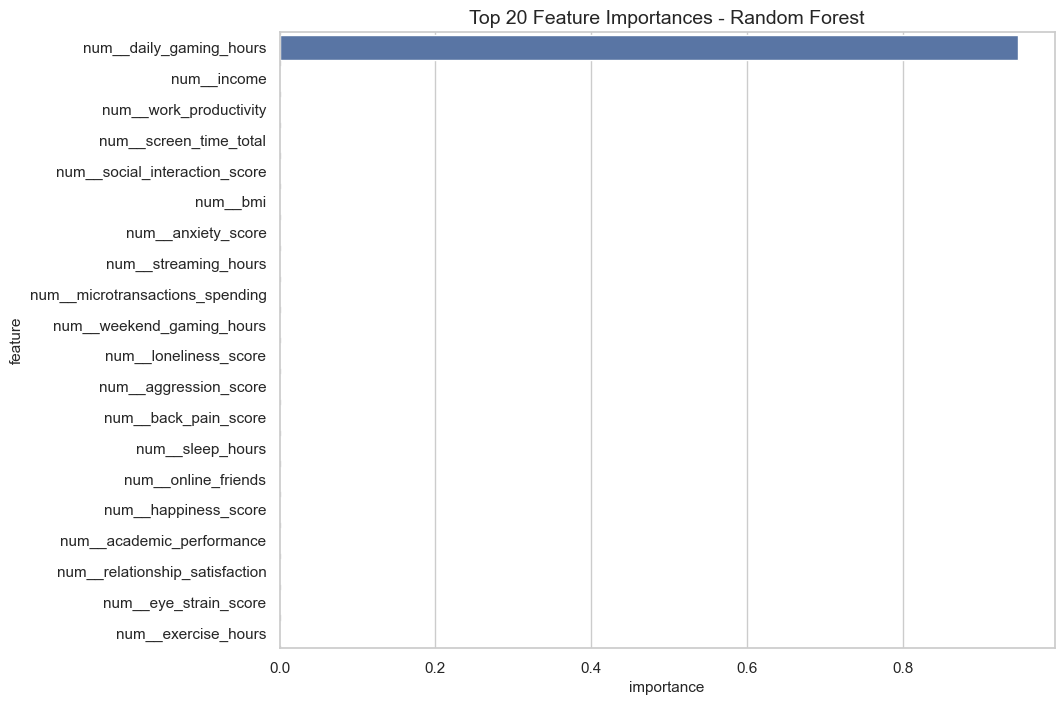

In [30]:
top_feats = feat_imp.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_feats, x="importance", y="feature")
plt.title("Top 20 Feature Importances - Random Forest")
plt.show()

In [31]:
single_sample = X_test.iloc[[0]]
single_actual = y_test.iloc[0]
single_pred = best_model.predict(single_sample)[0]

print("Actual :", single_actual)
print("Predicted :", single_pred)
single_sample

Actual : 1.77
Predicted : 3.1215048191072037


,age,gender,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,...,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
75721,50,Other,63534,4.51,11,21,7.0,1.24,5.17,5,...,3,5.43,4.93,4.68,23.71,7.55,6.14,1.97,98,2


In [32]:
new_user = pd.DataFrame([{
    "age": 24,
    "gender": "Male",
    "income": 25000,
    "daily_gaming_hours": 6.5,
    "weekly_sessions": 12,
    "years_gaming": 8,
    "sleep_hours": 5.8,
    "caffeine_intake": 3.0,
    "exercise_hours": 1.5,
    "stress_level": 7,
    "anxiety_score": 7.2,
    "depression_score": 6.4,
    "social_interaction_score": 4.0,
    "relationship_satisfaction": 5.1,
    "academic_performance": 6.0,
    "work_productivity": 5.7,
    "multiplayer_ratio": 0.82,
    "toxic_exposure": 6.5,
    "violent_games_ratio": 0.60,
    "mobile_gaming_ratio": 0.25,
    "night_gaming_ratio": 0.73,
    "weekend_gaming_hours": 8.4,
    "friends_gaming_count": 6,
    "online_friends": 15,
    "streaming_hours": 2.4,
    "esports_interest": 1,
    "headset_usage": 1,
    "microtransactions_spending": 180.0,
    "parental_supervision": 0,
    "loneliness_score": 7.5,
    "aggression_score": 6.1,
    "happiness_score": 4.2,
    "bmi": 24.8,
    "screen_time_total": 10.5,
    "eye_strain_score": 6.8,
    "back_pain_score": 5.1,
    "competitive_rank": 72,
    "internet_quality": 8
}])

pred_value = best_model.predict(new_user)[0]
print("Predicted addiction_level:", pred_value)

Predicted addiction_level: 4.491192488550507
